# 🤖 Analyse de Sentiments — DarijaBERT

**Modèle :** `SI2M-Lab/DarijaBERT`  
**Tâche :** Classification ternaire — `Positive` / `Negative` / `Neutral`  
**Langue :** Darija (Arabizi latin + arabe)

---

### ⚠️ Note importante — Données déséquilibrées

> Le dataset est **déséquilibré** (classes non équilibrées).  
> Pour éviter que le modèle apprenne à favoriser la classe majoritaire,  
> on utilise des **class weights** inversement proportionnels à la fréquence de chaque classe.  
> Ces poids sont injectés dans la loss function (`CrossEntropyLoss`).

---

### 📌 Ce que ce notebook fait

1. Charge les données **déjà nettoyées** (`dataset_clean.csv`)
2. Gère les **emojis** (3 stratégies au choix)
3. Fine-tune **DarijaBERT** avec class weights
4. Évalue avec **matrice de confusion** + rapport de classification complet

## 📦 Cellule 1 — Installation des dépendances

In [ ]:
%%capture
!pip install transformers datasets emoji scikit-learn seaborn matplotlib torch

## 📦 Cellule 2 — Imports

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
import emoji
import warnings
warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device : {DEVICE}")

✓ Device : cuda


## ⚙️ Cellule 3 — Configuration globale

> Modifiez ici les paramètres clés selon vos besoins.

In [ ]:
# ── Chemins ───────────────────────────────────────────────────────────────────
BASE_PATH       = "/content/drive/MyDrive/analyse_de_sentiments"
DATA_PATH       = os.path.join(BASE_PATH, "dataset_preprocessed.csv")   # données déjà nettoyées
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "darija_bert_model")

# ── Modèle ────────────────────────────────────────────────────────────────────
MODEL_NAME = "SI2M-Lab/DarijaBERT-Arabizi"

# ── Hyperparamètres ───────────────────────────────────────────────────────────
MAX_LEN        = 128
BATCH_SIZE     = 16
NUM_EPOCHS     = 2
LEARNING_RATE  = 2e-5
WARMUP_RATIO   = 0.1

# ── Colonnes du CSV ───────────────────────────────────────────────────────────
TEXT_COL  = "texte"
LABEL_COL = "label"

# ─────────────────────────────────────────────────────────────────────────────
# STRATÉGIE EMOJIS — Choisissez UNE option :
#
#   "keep"     → les emojis restent tels quels dans le texte
#   "replace"  → les emojis sont remplacés par leur sentiment (pos/neg/neutre)
#   "remove"   → les emojis sont supprimés du texte
# ─────────────────────────────────────────────────────────────────────────────
EMOJI_STRATEGY = "replace"

print(f"✓ Modèle    : {MODEL_NAME}")
print(f"✓ Stratégie emojis : {EMOJI_STRATEGY}")
print(f"✓ Epochs    : {NUM_EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LEARNING_RATE}")

✓ Modèle    : SI2M-Lab/DarijaBERT-Arabizi
✓ Stratégie emojis : replace
✓ Epochs    : 2  |  Batch : 16  |  LR : 2e-05


##  Cellule 4 — Montage Drive + Chargement des données

Mounted at /content/drive
DATASET CHARGÉ (déjà nettoyé — cleaning déjà effectué)
  Taille totale : 39,834 lignes
  Colonnes      : ['texte', 'label']

Distribution des labels :
label
Positive    16527
Negative    15796
Neutral      7511


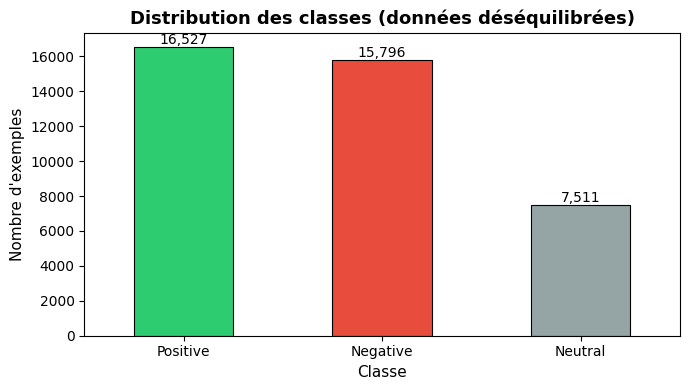


                                               texte     label
0  ماكينة عجباتني كاتحيد شعر من الجدر ومكاتخليش ل...  Positive
1   واعرة كاتشد الشارج لمدة طويلة وساهلة فالخدمة ...  Positive
2  زوينة وصغيرة ومطيورة كيما كايقولو هههه، فلوسها...  Positive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Chargement ────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)

print("=" * 60)
print("DATASET CHARGÉ (déjà nettoyé — cleaning déjà effectué)")
print("=" * 60)
print(f"  Taille totale : {len(df):,} lignes")
print(f"  Colonnes      : {df.columns.tolist()}")
print()

# ── Distribution des classes ──────────────────────────────────────────────────
print("Distribution des labels :")
vc = df[LABEL_COL].value_counts()
print(vc.to_string())

# ── Visualisation distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
vc.plot(kind="bar", ax=ax, color=colors, edgecolor="black", linewidth=0.8)
ax.set_title("Distribution des classes (données déséquilibrées)", fontsize=13, fontweight="bold")
ax.set_xlabel("Classe", fontsize=11)
ax.set_ylabel("Nombre d'exemples", fontsize=11)
ax.tick_params(axis="x", rotation=0)
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height()):,}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("distribution_classes.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print(df.head(3))

##  Cellule 5 — Traitement des Emojis


In [ ]:
# ── Dictionnaire de sentiment des emojis ──────────────────────────────────────
# Emojis positifs courants
EMOJI_POSITIF = {
    "😊","😁","😄","😃","🥰","😍","🤩","😎","👍","💪","🎉","🎊","❤️",
    "💕","💖","💗","💓","💞","🌟","⭐","✨","🙏","👏","😉","🥳","🤗",
    "😀","😆","☺️","🤭","💯","🔥","👌","🤙","✅","🌹","😋","🥹","😇"
}

# Emojis négatifs courants
EMOJI_NEGATIF = {
    "😢","😭","😡","🤬","💔","😤","😠","👎","😞","😔","😟","🥺","😿",
    "😣","😫","😩","🤯","🙁","☹️","😖","😒","🤮","🤢","💀","☠️","🖕",
    "😬","😵","🤕","🤒","🥵","🥶","😰","😨","😱","🫠","🤧"
}


def handle_emojis(text: str, strategy: str) -> str:
    """
    Traite les emojis selon la stratégie choisie.

    Paramètres
    ----------
    text     : texte à traiter
    strategy : 'keep' | 'replace' | 'remove'

    Retourne
    --------
    str : texte avec emojis traités
    """
    text = str(text)

    if strategy == "keep":
        # Rien à faire — les emojis restent tels quels
        return text

    elif strategy == "remove":
        # Suppression de tous les emojis
        return emoji.replace_emoji(text, replace="")

    elif strategy == "replace":
        # Remplacement par token de sentiment
        result = []
        for char in text:
            if emoji.is_emoji(char):
                if char in EMOJI_POSITIF:
                    result.append(" __EMOJI_POS__ ")
                elif char in EMOJI_NEGATIF:
                    result.append(" __EMOJI_NEG__ ")
                else:
                    result.append(" __EMOJI_NEU__ ")  # neutre par défaut
            else:
                result.append(char)
        return re.sub(r'\s+', ' ', ''.join(result)).strip()

    else:
        raise ValueError(f"Stratégie inconnue : '{strategy}'. Choisissez 'keep', 'replace' ou 'remove'.")


# ── Application ───────────────────────────────────────────────────────────────
df["texte_processed"] = df[TEXT_COL].apply(lambda x: handle_emojis(x, EMOJI_STRATEGY))

print(f"✓ Stratégie emojis appliquée : '{EMOJI_STRATEGY}'")
print()

# ── Vérification sur quelques exemples ────────────────────────────────────────
print("Exemples de traitement des emojis :")
exemples = df[df[TEXT_COL].str.contains('|'.join(['😊','😢','❤️','👍','😭','💔']), na=False)].head(5)
if len(exemples) > 0:
    for _, row in exemples.iterrows():
        print(f"  Avant  : {row[TEXT_COL][:80]}")
        print(f"  Après  : {row['texte_processed'][:80]}")
        print()
else:
    print("  (Aucun exemple avec emoji trouvé dans les premières lignes)")

✓ Stratégie emojis appliquée : 'replace'

Exemples de traitement des emojis :
  Avant  : السلام جاو فوقيتة مناسبة ...هدية لولدي فرح بيهم بزاف 👍
  Après  : السلام جاو فوقيتة مناسبة ...هدية لولدي فرح بيهم بزاف __EMOJI_POS__

  Avant  : @AliiMezher enta 7elw w 3asal w 2eshta b kel 7alatek bas 3afekra enta dabdoub mo
  Après  : @AliiMezher enta 7elw w 3asal w 2eshta b kel 7alatek bas 3afekra enta dabdoub mo

  Avant  : Tsala lik lbouta w matkhsrch lik l brika 😭😭
  Après  : Tsala lik lbouta w matkhsrch lik l brika __EMOJI_NEG__ __EMOJI_NEG__

  Avant  : @__HaMaSa Wakhad 3lik nadra zwina insane rai3a i7ssas bik rhdyi tkon insan jamil
  Après  : @__HaMaSa Wakhad 3lik nadra zwina insane rai3a i7ssas bik rhdyi tkon insan jamil

  Avant  : @ne2s_u @diib_diibologie Ach katsna men wahd kayban lih niveau dial rap kaytle3 
  Après  : @ne2s_u @diib_diibologie Ach katsna men wahd kayban lih niveau dial rap kaytle3 



##  Cellule 6 — Encodage des Labels

In [ ]:
# ── Normalisation des labels ──────────────────────────────────────────────────
df[LABEL_COL] = df[LABEL_COL].str.strip().str.capitalize()

# Vérification que les labels sont bien Positive / Negative / Neutral
labels_attendus = {"Positive", "Negative", "Neutral"}
labels_trouves  = set(df[LABEL_COL].unique())
diff = labels_trouves - labels_attendus
if diff:
    print(f"⚠️  Labels inconnus détectés : {diff}")
    print("    → Suppression de ces lignes.")
    df = df[df[LABEL_COL].isin(labels_attendus)].reset_index(drop=True)
else:
    print("✓ Labels valides : Positive / Negative / Neutral")

# ── Encodage numérique ────────────────────────────────────────────────────────
LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

df["label_id"] = df[LABEL_COL].map(LABEL2ID)

print(f"\n  Mapping : {LABEL2ID}")
print(f"  Distribution après encodage :")
print(df["label_id"].value_counts().sort_index().to_string())

✓ Labels valides : Positive / Negative / Neutral

  Mapping : {'Negative': 0, 'Neutral': 1, 'Positive': 2}
  Distribution après encodage :
label_id
0    15796
1     7511
2    16527


##  Cellule 7 — Train / Validation / Test Split

In [ ]:
# ── Stratified split : 80% train / 10% val / 10% test ─────────────────────────
df_train, df_temp = train_test_split(
    df, test_size=0.2, stratify=df["label_id"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp["label_id"], random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print("=" * 50)
print("RÉPARTITION DU DATASET")
print("=" * 50)
print(f"  Train      : {len(df_train):>6,} exemples  ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Validation : {len(df_val):>6,} exemples  ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test       : {len(df_test):>6,} exemples  ({len(df_test)/len(df)*100:.1f}%)")
print()
print("Distribution des classes dans le train :")
print(df_train[LABEL_COL].value_counts().to_string())

RÉPARTITION DU DATASET
  Train      : 31,867 exemples  (80.0%)
  Validation :  3,983 exemples  (10.0%)
  Test       :  3,984 exemples  (10.0%)

Distribution des classes dans le train :
label
Positive    13221
Negative    12637
Neutral      6009


##  Cellule 8 — Class Weights



In [ ]:
# ── Calcul des class weights (sur le train uniquement) ────────────────────────
classes       = np.array(sorted(LABEL2ID.values()))  # [0, 1, 2]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label_id"].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("=" * 55)
print("CLASS WEIGHTS — Correction du déséquilibre")
print("=" * 55)
for label_id, weight in zip(classes, class_weights):
    label_name = ID2LABEL[label_id]
    count      = (df_train["label_id"] == label_id).sum()
    print(f"  {label_name:<12} (id={label_id}) : weight = {weight:.4f}  (n={count:,})")

print()
print("ℹ  Interprétation : plus le poids est élevé, plus la classe est rare.")
print("   La loss sera multipliée par ce poids pour chaque exemple mal classé.")

CLASS WEIGHTS — Correction du déséquilibre
  Negative     (id=0) : weight = 0.8406  (n=12,637)
  Neutral      (id=1) : weight = 1.7677  (n=6,009)
  Positive     (id=2) : weight = 0.8034  (n=13,221)

ℹ️  Interprétation : plus le poids est élevé, plus la classe est rare.
   La loss sera multipliée par ce poids pour chaque exemple mal classé.


##  Cellule 9 — Tokenizer DarijaBERT

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✓ Tokenizer chargé : {MODEL_NAME}")
print(f"  Vocab size : {tokenizer.vocab_size:,}")

# ── Test rapide ───────────────────────────────────────────────────────────────
exemple = df_train["texte_processed"].iloc[0]
tokens  = tokenizer.tokenize(exemple[:200])
print(f"\n  Exemple : '{exemple[:80]}...'")
print(f"  Tokens  : {tokens[:15]}...")

config.json:   0%|          | 0.00/787 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Tokenizer chargé : SI2M-Lab/DarijaBERT-Arabizi
  Vocab size : 110,000

  Exemple : 'ههههه هادشي كولو على حسب واحد مؤتمر غادي يكون في مراكش ومن بعد سد على كولشي...'
  Tokens  : ['ه', '##هه', '##هه', 'هادشي', 'كول', '##و', 'على', 'حسب', 'واحد', 'موت', '##مر', 'غادي', 'يكون', 'في', 'مراكش']...


##  Cellule 10 — Dataset PyTorch

In [ ]:
class DarijaDataset(Dataset):
    """
    Dataset PyTorch pour la classification de sentiments en Darija.
    Compatible DarijaBERT / CamemBERT / AraBERT et tout modèle HuggingFace.
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ── Création des datasets ─────────────────────────────────────────────────────
train_dataset = DarijaDataset(
    df_train["texte_processed"].tolist(),
    df_train["label_id"].tolist(),
    tokenizer, MAX_LEN
)

val_dataset = DarijaDataset(
    df_val["texte_processed"].tolist(),
    df_val["label_id"].tolist(),
    tokenizer, MAX_LEN
)

test_dataset = DarijaDataset(
    df_test["texte_processed"].tolist(),
    df_test["label_id"].tolist(),
    tokenizer, MAX_LEN
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✓ Datasets créés")
print(f"  Train  : {len(train_dataset):,} exemples — {len(train_loader):,} batches")
print(f"  Val    : {len(val_dataset):,} exemples — {len(val_loader):,} batches")
print(f"  Test   : {len(test_dataset):,} exemples — {len(test_loader):,} batches")

✓ Datasets créés
  Train  : 31,867 exemples — 1,992 batches
  Val    : 3,983 exemples — 249 batches
  Test   : 3,984 exemples — 249 batches


## Cellule 11 — Modèle DarijaBERT

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
model = model.to(DEVICE)

# ── Résumé du modèle ──────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Modèle chargé : {MODEL_NAME}")
print(f"  Paramètres totaux      : {total_params:,}")
print(f"  Paramètres entraînables: {trainable_params:,}")
print(f"  Classes                : {ID2LABEL}")

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: SI2M-Lab/DarijaBERT-Arabizi
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you 

✓ Modèle chargé : SI2M-Lab/DarijaBERT-Arabizi
  Paramètres totaux      : 170,523,651
  Paramètres entraînables: 170,523,651
  Classes                : {0: 'Negative', 1: 'Neutral', 2: 'Positive'}


##  Cellule 12 — Fonctions d'entraînement et d'évaluation

In [ ]:
# ── Loss avec class weights ───────────────────────────────────────────────────
# NOTE : c'est ici que les class weights sont appliqués.
# La CrossEntropyLoss multiplie la perte de chaque exemple par le poids
# de sa classe, forçant le modèle à mieux apprendre les classes rares.
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── Optimiseur ────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# ── Scheduler avec warmup ─────────────────────────────────────────────────────
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


def train_epoch(model, loader, optimizer, scheduler, criterion):
    """Entraîne le modèle sur une époque."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    """Évalue le modèle sur un loader (val ou test)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


print("✓ Fonctions d'entraînement et d'évaluation définies")
print(f"  Total steps  : {total_steps}")
print(f"  Warmup steps : {warmup_steps}")

✓ Fonctions d'entraînement et d'évaluation définies
  Total steps  : 3984
  Warmup steps : 398


##  Cellule 13 — Entraînement

In [ ]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": []
}

best_val_f1   = 0.0
best_epoch    = 0
patience      = 3        # early stopping
no_improve    = 0

print("=" * 70)
print("ENTRAÎNEMENT DarijaBERT — avec class weights")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────────
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion)

    # ── Validation ─────────────────────────────────────────────────────────────
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"  Epoch {epoch}/{NUM_EPOCHS} "
          f"| Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1-macro: {val_f1:.4f}")

    # ── Sauvegarde du meilleur modèle (selon F1-macro) ─────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        no_improve  = 0
        model.save_pretrained(MODEL_SAVE_PATH)
        tokenizer.save_pretrained(MODEL_SAVE_PATH)
        print(f"    ✅ Meilleur modèle sauvegardé (F1={best_val_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"    ⚠️  Early stopping à l'epoch {epoch} (pas d'amélioration depuis {patience} epochs)")
            break

print()
print(f"✓ Entraînement terminé. Meilleur epoch : {best_epoch} | F1-macro val : {best_val_f1:.4f}")

ENTRAÎNEMENT DarijaBERT — avec class weights
  Epoch 1/2 | Train Loss: 0.4562  Acc: 0.8129 | Val Loss: 0.3417  Acc: 0.8677  F1-macro: 0.8558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    ✅ Meilleur modèle sauvegardé (F1=0.8558)
  Epoch 2/2 | Train Loss: 0.2497  Acc: 0.9100 | Val Loss: 0.3901  Acc: 0.8805  F1-macro: 0.8692


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    ✅ Meilleur modèle sauvegardé (F1=0.8692)

✓ Entraînement terminé. Meilleur epoch : 2 | F1-macro val : 0.8692


##  Cellule 14 — Courbes d'apprentissage

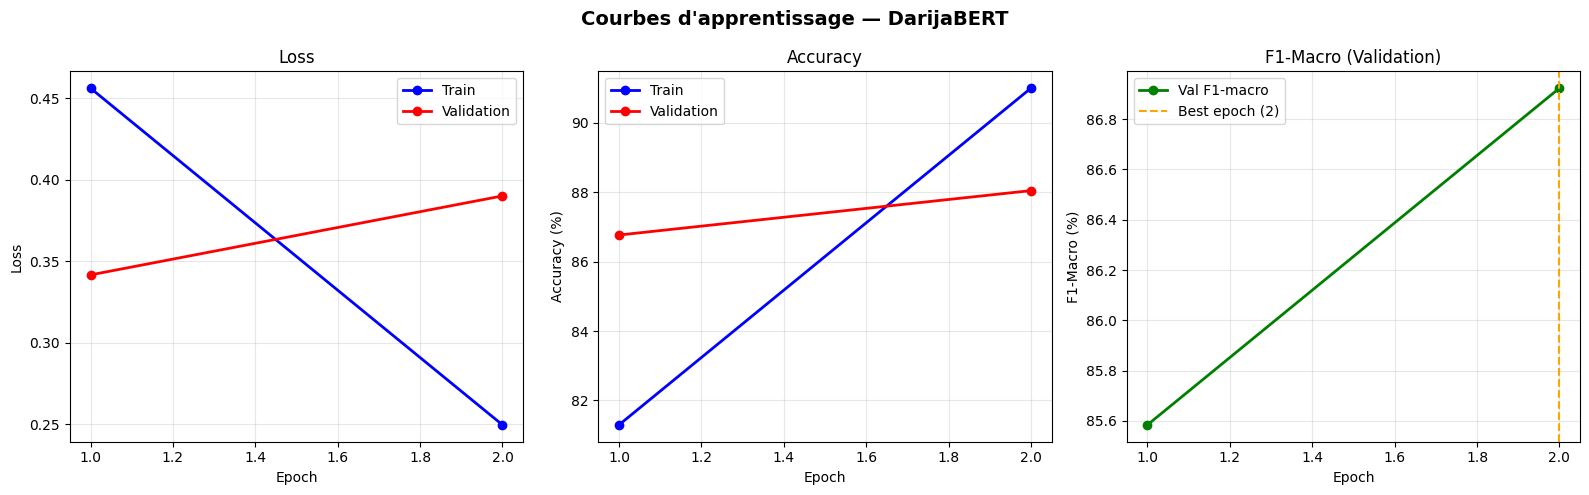

✓ Courbes sauvegardées : courbes_apprentissage.png


In [ ]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Courbes d'apprentissage — DarijaBERT", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(epochs_ran, history["train_loss"], "b-o", label="Train",      linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   "r-o", label="Validation", linewidth=2)
axes[0].set_title("Loss",     fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, [a * 100 for a in history["train_acc"]], "b-o", label="Train",      linewidth=2)
axes[1].plot(epochs_ran, [a * 100 for a in history["val_acc"]],   "r-o", label="Validation", linewidth=2)
axes[1].set_title("Accuracy", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1-macro
axes[2].plot(epochs_ran, [f * 100 for f in history["val_f1"]], "g-o", label="Val F1-macro", linewidth=2)
axes[2].axvline(x=best_epoch, color="orange", linestyle="--", label=f"Best epoch ({best_epoch})")
axes[2].set_title("F1-Macro (Validation)", fontsize=12)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1-Macro (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("courbes_apprentissage.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Courbes sauvegardées : courbes_apprentissage.png")

##  Cellule 15 — Évaluation finale sur le Test Set

> On recharge le **meilleur modèle** sauvegardé avant d'évaluer sur le test.

In [ ]:
# ── Rechargement du meilleur modèle ──────────────────────────────────────────
best_model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
best_model = best_model.to(DEVICE)
print(f"✓ Meilleur modèle rechargé depuis : {MODEL_SAVE_PATH}")

# ── Évaluation test ───────────────────────────────────────────────────────────
test_loss, test_acc, test_preds, test_labels = evaluate(best_model, test_loader, criterion)

test_f1        = f1_score(test_labels, test_preds, average="macro")
test_f1_weight = f1_score(test_labels, test_preds, average="weighted")

class_names = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]

print()
print("=" * 60)
print("RÉSULTATS FINAUX — TEST SET")
print("=" * 60)
print(f"  Accuracy          : {test_acc * 100:.2f}%")
print(f"  F1-Score macro    : {test_f1 * 100:.2f}%")
print(f"  F1-Score weighted : {test_f1_weight * 100:.2f}%")
print(f"  Loss              : {test_loss:.4f}")
print()
print("Rapport de classification détaillé :")
print(classification_report(
    test_labels, test_preds,
    target_names=class_names,
    digits=4
))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Meilleur modèle rechargé depuis : /content/drive/MyDrive/analyse_de_sentiments/darija_bert_model

RÉSULTATS FINAUX — TEST SET
  Accuracy          : 87.50%
  F1-Score macro    : 85.93%
  F1-Score weighted : 87.54%
  Loss              : 0.4126

Rapport de classification détaillé :
              precision    recall  f1-score   support

    Negative     0.9059    0.8772    0.8913      1580
     Neutral     0.7691    0.8029    0.7857       751
    Positive     0.8964    0.9056    0.9010      1653

    accuracy                         0.8750      3984
   macro avg     0.8571    0.8619    0.8593      3984
weighted avg     0.8762    0.8750    0.8754      3984



##  Cellule 16 — Matrice de Confusion

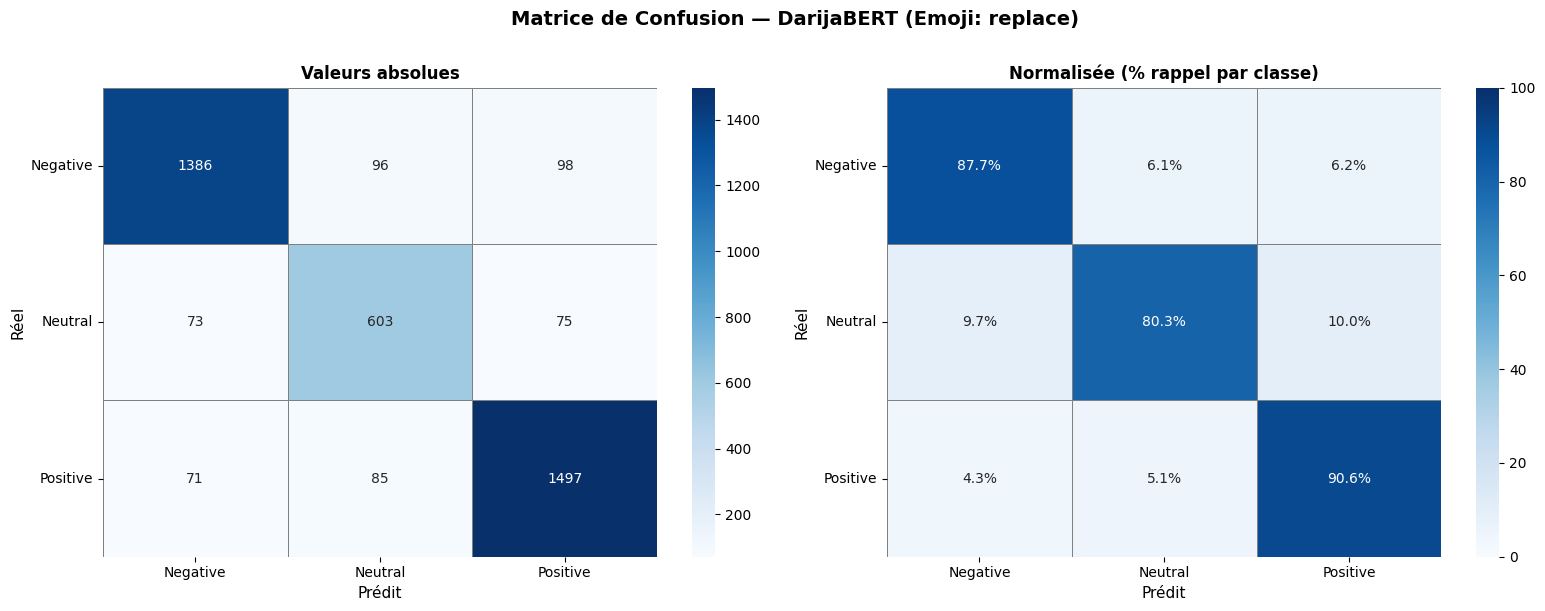

✓ Matrice de confusion sauvegardée : confusion_matrix.png


In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Matrice de Confusion",
                          save_path="confusion_matrix.png"):
    """
    Trace une matrice de confusion professionnelle avec :
    - Valeurs absolues
    - Pourcentages par ligne (rappel par classe)
    """
    cm   = confusion_matrix(y_true, y_pred)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # normalisation par ligne

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    # ── 1. Matrice absolue ────────────────────────────────────────────────────
    sns.heatmap(
        cm, annot=True, fmt="d",
        cmap="Blues", ax=axes[0],
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5, linecolor="gray"
    )
    axes[0].set_title("Valeurs absolues",  fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Prédit",           fontsize=11)
    axes[0].set_ylabel("Réel",             fontsize=11)
    axes[0].tick_params(axis="x", rotation=0)
    axes[0].tick_params(axis="y", rotation=0)

    # ── 2. Matrice normalisée (% par ligne) ──────────────────────────────────
    annot = np.array([[f"{v:.1f}%" for v in row] for row in cm_n])
    sns.heatmap(
        cm_n, annot=annot, fmt="",
        cmap="Blues", ax=axes[1],
        xticklabels=class_names,
        yticklabels=class_names,
        vmin=0, vmax=100,
        linewidths=0.5, linecolor="gray"
    )
    axes[1].set_title("Normalisée (% rappel par classe)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Prédit",                          fontsize=11)
    axes[1].set_ylabel("Réel",                            fontsize=11)
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Matrice de confusion sauvegardée : {save_path}")


plot_confusion_matrix(
    test_labels, test_preds,
    class_names=class_names,
    title=f"Matrice de Confusion — DarijaBERT (Emoji: {EMOJI_STRATEGY})",
    save_path="confusion_matrix.png"
)

##  Cellule 17 — Résumé final

In [ ]:
from sklearn.metrics import classification_report
import json

# ── Rapport complet en dict ───────────────────────────────────────────────────
report_dict = classification_report(
    test_labels, test_preds,
    target_names=class_names,
    output_dict=True,
    digits=4
)

# ── Tableau récapitulatif ─────────────────────────────────────────────────────
rows = []
for label in class_names:
    r = report_dict[label]
    rows.append({
        "Classe":    label,
        "Précision": f"{r['precision']*100:.2f}%",
        "Rappel":    f"{r['recall']*100:.2f}%",
        "F1-Score":  f"{r['f1-score']*100:.2f}%",
        "Support":   int(r['support'])
    })

df_results = pd.DataFrame(rows)

print("=" * 70)
print("RÉSUMÉ FINAL DU MODÈLE DarijaBERT")
print("=" * 70)
print(f"  Modèle            : {MODEL_NAME}")
print(f"  Stratégie emojis  : {EMOJI_STRATEGY}")
print(f"  Class weights     : ✅ (données déséquilibrées corrigées)")
print(f"  Meilleur epoch    : {best_epoch} / {NUM_EPOCHS}")
print()
print("  Métriques globales :")
print(f"    Accuracy          : {test_acc * 100:.2f}%")
print(f"    F1-macro          : {test_f1 * 100:.2f}%")
print(f"    F1-weighted       : {test_f1_weight * 100:.2f}%")
print()
print("  Métriques par classe :")
print(df_results.to_string(index=False))
print()

# ── Sauvegarde JSON ───────────────────────────────────────────────────────────
results_to_save = {
    "model":          MODEL_NAME,
    "emoji_strategy": EMOJI_STRATEGY,
    "class_weights":  {ID2LABEL[i]: float(w) for i, w in enumerate(class_weights)},
    "best_epoch":     best_epoch,
    "test_accuracy":  round(test_acc, 4),
    "test_f1_macro":  round(test_f1, 4),
    "test_f1_weighted": round(test_f1_weight, 4),
    "per_class":      {label: report_dict[label] for label in class_names}
}

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results_to_save, f, ensure_ascii=False, indent=2)

print("✓ Résultats sauvegardés : results.json")
print(f"✓ Modèle sauvegardé    : {MODEL_SAVE_PATH}")

RÉSUMÉ FINAL DU MODÈLE DarijaBERT
  Modèle            : SI2M-Lab/DarijaBERT-Arabizi
  Stratégie emojis  : replace
  Class weights     : ✅ (données déséquilibrées corrigées)
  Meilleur epoch    : 2 / 2

  Métriques globales :
    Accuracy          : 87.50%
    F1-macro          : 85.93%
    F1-weighted       : 87.54%

  Métriques par classe :
  Classe Précision Rappel F1-Score  Support
Negative    90.59% 87.72%   89.13%     1580
 Neutral    76.91% 80.29%   78.57%      751
Positive    89.64% 90.56%   90.10%     1653

✓ Résultats sauvegardés : results.json
✓ Modèle sauvegardé    : /content/drive/MyDrive/analyse_de_sentiments/darija_bert_model


##  Cellule 18 — Inférence sur de nouveaux textes

In [ ]:
def predict_sentiment(texts, model, tokenizer, strategy=EMOJI_STRATEGY):
    """
    Prédit le sentiment de nouveaux textes en Darija.

    Paramètres
    ----------
    texts    : str ou list[str]
    model    : modèle chargé
    tokenizer: tokenizer chargé
    strategy : stratégie emoji (héritée de la config)

    Retourne
    --------
    DataFrame avec texte, label prédit, et probabilités
    """
    if isinstance(texts, str):
        texts = [texts]

    processed = [handle_emojis(t, strategy) for t in texts]

    model.eval()
    all_preds, all_probs = [], []

    with torch.no_grad():
        for text in processed:
            enc = tokenizer(
                text,
                max_length=MAX_LEN,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            ).to(DEVICE)

            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred   = np.argmax(probs)

            all_preds.append(ID2LABEL[pred])
            all_probs.append(probs)

    df_pred = pd.DataFrame({
        "texte":    texts,
        "label":    all_preds,
        "P(Negative)": [p[0] for p in all_probs],
        "P(Neutral)":  [p[1] for p in all_probs],
        "P(Positive)": [p[2] for p in all_probs],
    })

    return df_pred


# ── Test sur quelques exemples ────────────────────────────────────────────────
exemples_test = [
    "hada restaurant zwine bzzaf, klit mezyan 😊",
    "ma3jbniش had lfilm, mshum bzzaf 😢",
    "khedma oukay, machi mzyana machi khaiba",
    "خدمة مزيانة وسريعة ❤️",
    "hadchi mazwin makhayb 3adi jidan osf 3adi   "
]

df_inference = predict_sentiment(exemples_test, best_model, tokenizer)

print("=" * 70)
print("INFÉRENCE — Exemples de prédiction")
print("=" * 70)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
print(df_inference.to_string(index=False))

INFÉRENCE — Exemples de prédiction
                                       texte    label  P(Negative)  P(Neutral)  P(Positive)
  hada restaurant zwine bzzaf, klit mezyan 😊 Positive        0.002       0.001        0.998
           ma3jbniش had lfilm, mshum bzzaf 😢 Negative        0.999       0.000        0.001
     khedma oukay, machi mzyana machi khaiba Negative        0.753       0.193        0.053
                       خدمة مزيانة وسريعة ❤️ Positive        0.002       0.000        0.997
hadchi mazwin makhayb 3adi jidan osf 3adi     Neutral        0.342       0.643        0.015
